# Length-Normalized IPO vs Standard IPO Comparison

이 notebook은 Qwen3-0.6B에서 length normalization을 적용한 IPO variants를 standard IPO baseline과 비교합니다.

비교 대상:

- `standard_ipo+mean`
- `standard_ipo+sqrt`
- `target_ratio+mean=0.7/0.8`
- `target_ratio+sqrt=0.7/0.8`

포함 내용:

1. Norm variant 학습 로그 요약
2. Train loss, actual ratio, reward accuracy, reward margin curve
3. Standard IPO 대비 benchmark 비교
4. Task별 delta 및 평균 점수 ranking


In [40]:
from pathlib import Path
import os
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

ROOT = Path.cwd()
os.environ["HF_HOME"] = str(ROOT / ".hf_cache")
os.environ["HF_DATASETS_CACHE"] = str(ROOT / ".hf_cache" / "datasets")
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

BENCHMARK_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "benchmark_comparison.csv"
TRAINING_SUMMARY_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "training_log_summary.csv"
benchmark_all = pd.read_csv(BENCHMARK_CSV)
training_all = pd.read_csv(TRAINING_SUMMARY_CSV)

def latest_state_path(run_dir):
    paths = sorted(
        Path(run_dir).glob("checkpoint-*/trainer_state.json"),
        key=lambda p: int(re.search(r"checkpoint-(\d+)", str(p)).group(1)),
    )
    return paths[-1] if paths else None

def load_state(path):
    with open(path, "r") as f:
        return json.load(f)

def load_curves(run_rows):
    rows = []
    for row in run_rows:
        state_path = latest_state_path(row["run_dir"])
        if state_path is None:
            continue
        state = load_state(state_path)
        for item in state.get("log_history", []):
            step = item.get("step")
            if step is None:
                continue
            if "loss" in item:
                rows.append({
                    "model": row["model"],
                    "split": "train",
                    "step": step,
                    "epoch": item.get("epoch"),
                    "loss": item.get("loss"),
                    "actual_ratio": item.get("target_ratio/actual"),
                    "reward_accuracy": item.get("rewards/accuracies"),
                    "reward_margin": item.get("rewards/margins"),
                    "learning_rate": item.get("learning_rate"),
                    "grad_norm": item.get("grad_norm"),
                })
            if "eval_loss" in item:
                rows.append({
                    "model": row["model"],
                    "split": "eval",
                    "step": step,
                    "epoch": item.get("epoch"),
                    "loss": item.get("eval_loss"),
                    "actual_ratio": item.get("eval_target_ratio/actual"),
                    "reward_accuracy": item.get("eval_rewards/accuracies"),
                    "reward_margin": item.get("eval_rewards/margins"),
                    "learning_rate": np.nan,
                    "grad_norm": np.nan,
                })
    return pd.DataFrame(rows)

def lineplot_metric(curves, metric, title=None, ylabel=None, ylim=None):
    df = curves.dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model", style="split")
    else:
        for (model, split), g in df.groupby(["model", "split"]):
            plt.plot(g["step"], g[metric], label=f"{model} {split}")
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

def lineplot_train_metric(curves, metric, title=None, ylabel=None, ylim=None):
    df = curves[curves["split"].eq("train")].dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model")
    else:
        for model, g in df.groupby("model"):
            plt.plot(g["step"], g[metric], label=model)
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()


In [41]:
def plot_train_actual_ratio(curves, title="Train Actual Ratio", ylim=None):
    train_df = curves[(curves["split"].eq("train")) & curves["actual_ratio"].notna()].copy()
    if train_df.empty:
        print("No train actual_ratio values found.")
        return
    plt.figure(figsize=(10.5, 4.8))
    if sns:
        sns.lineplot(data=train_df, x="step", y="actual_ratio", hue="model")
    else:
        for model, g in train_df.groupby("model"):
            plt.plot(g["step"], g["actual_ratio"], label=model)
        plt.legend()
    plt.title(title)
    plt.xlabel("step")
    plt.ylabel("train actual_ratio")
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

In [42]:

NORM_ROOT = ROOT / "outputs" / "length_normalized_ipo" / "20260607"

def parse_norm_run(run_dir):
    name = Path(run_dir).name
    m = re.search(r"objective_target_ratio_norm_([^_]+)_ratio_([0-9.]+)_", name)
    if m:
        norm = m.group(1)
        ratio = float(m.group(2))
        return {
            "model": f"target_ratio+{norm}={ratio:.1f}",
            "objective": "target_ratio",
            "length_norm": norm,
            "target_ratio": ratio,
        }
    m = re.search(r"objective_standard_ipo_norm_([^_]+)_", name)
    if m:
        norm = m.group(1)
        return {
            "model": f"standard_ipo+{norm}",
            "objective": "standard_ipo",
            "length_norm": norm,
            "target_ratio": np.nan,
        }
    return None

run_rows = []
for run_dir in sorted(NORM_ROOT.iterdir() if NORM_ROOT.exists() else []):
    if not run_dir.is_dir():
        continue
    meta = parse_norm_run(run_dir)
    if meta is None:
        continue
    run_rows.append({
        **meta,
        "run_dir": run_dir,
        "final_dir": run_dir / "final",
        "latest_state": latest_state_path(run_dir),
        "has_final": (run_dir / "final" / "model.safetensors").exists(),
    })

runs = pd.DataFrame(run_rows).sort_values(["objective", "length_norm", "target_ratio"], na_position="last")
runs


,model,objective,length_norm,target_ratio,run_dir,final_dir,latest_state,has_final
0,standard_ipo+mean,standard_ipo,mean,NaN,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True
1,standard_ipo+sqrt,standard_ipo,sqrt,NaN,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True
2,target_ratio+mean=0.7,target_ratio,mean,0.7,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True
3,target_ratio+mean=0.8,target_ratio,mean,0.8,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True
4,target_ratio+sqrt=0.7,target_ratio,sqrt,0.7,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True
5,target_ratio+sqrt=0.8,target_ratio,sqrt,0.8,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,/home/cvip/qwen3_ipo_exp/outputs/length_normal...,True


In [43]:

norm_models = [
    "standard_ipo+mean", "standard_ipo+sqrt",
    "target_ratio+mean=0.7", "target_ratio+mean=0.8",
    "target_ratio+sqrt=0.7", "target_ratio+sqrt=0.8",
]
mean_models = ["standard_ipo+mean", "target_ratio+mean=0.7", "target_ratio+mean=0.8"]
sqrt_models = ["standard_ipo+sqrt", "target_ratio+sqrt=0.7", "target_ratio+sqrt=0.8"]
summary = training_all[training_all["model"].isin(norm_models)].copy()
summary = summary.rename(columns={"chosen_target_ratio": "target_ratio"})
cols = [
    "model", "objective", "length_norm", "target_ratio", "global_step", "epoch",
    "final_train_loss", "final_eval_loss",
    "final_train_actual_ratio", "final_eval_actual_ratio",
    "final_eval_reward_accuracy", "final_eval_margin",
]
summary[cols]


,model,objective,length_norm,target_ratio,global_step,epoch,final_train_loss,final_eval_loss,final_train_actual_ratio,final_eval_actual_ratio,final_eval_reward_accuracy,final_eval_margin
3,standard_ipo+mean,standard_ipo,mean,NaN,2709,3.0,2259.645508,2443.218018,0.506934,0.502628,0.596277,0.010554
4,standard_ipo+sqrt,standard_ipo,sqrt,NaN,2709,3.0,1012.706348,2777.681641,0.556081,0.502173,0.552660,0.008685
5,target_ratio+mean=0.7,target_ratio,mean,0.7,2709,3.0,0.663107,0.700304,0.510120,0.505147,0.603191,0.020895
6,target_ratio+mean=0.8,target_ratio,mean,0.8,2709,3.0,1.836790,1.895193,0.508168,0.503128,0.604255,0.012570
7,target_ratio+sqrt=0.7,target_ratio,sqrt,0.7,2709,3.0,0.399750,0.757413,0.561565,0.502187,0.544681,0.008765
8,target_ratio+sqrt=0.8,target_ratio,sqrt,0.8,2709,3.0,1.319099,1.964205,0.564378,0.502327,0.552660,0.009451


In [44]:

curves = load_curves(run_rows)
curves.to_csv(ROOT / "outputs" / "analysis_ipo_variants" / "length_norm_training_curves.csv", index=False)
curves.tail()


,model,split,step,epoch,loss,actual_ratio,reward_accuracy,reward_margin,learning_rate,grad_norm
1783,target_ratio+sqrt=0.8,train,2680,2.967885,1.335053,0.561652,0.91250,0.250234,5.537099e-09,62.669563
1784,target_ratio+sqrt=0.8,train,2690,2.978959,1.475392,0.548922,0.80000,0.199424,3.691399e-09,72.972778
1785,target_ratio+sqrt=0.8,train,2700,2.990033,1.319099,0.564378,0.85000,0.262466,1.845700e-09,91.259201
1786,target_ratio+sqrt=0.8,eval,2700,2.990033,1.967469,0.502102,0.54734,0.008539,NaN,NaN
1787,target_ratio+sqrt=0.8,eval,2709,3.000000,1.964205,0.502327,0.55266,0.009451,NaN,NaN


## Train/Eval Reward Accuracy 분리 및 Gap

`reward_accuracy`는 benchmark accuracy가 아니라 preference pair에서 `chosen reward > rejected reward`인 비율입니다.  
Train과 eval의 범위가 크게 달라 한 그래프에 겹치면 차이가 잘 안 보이므로, 아래에서는 train/eval을 분리하고 마지막으로 train-eval gap을 확인합니다.

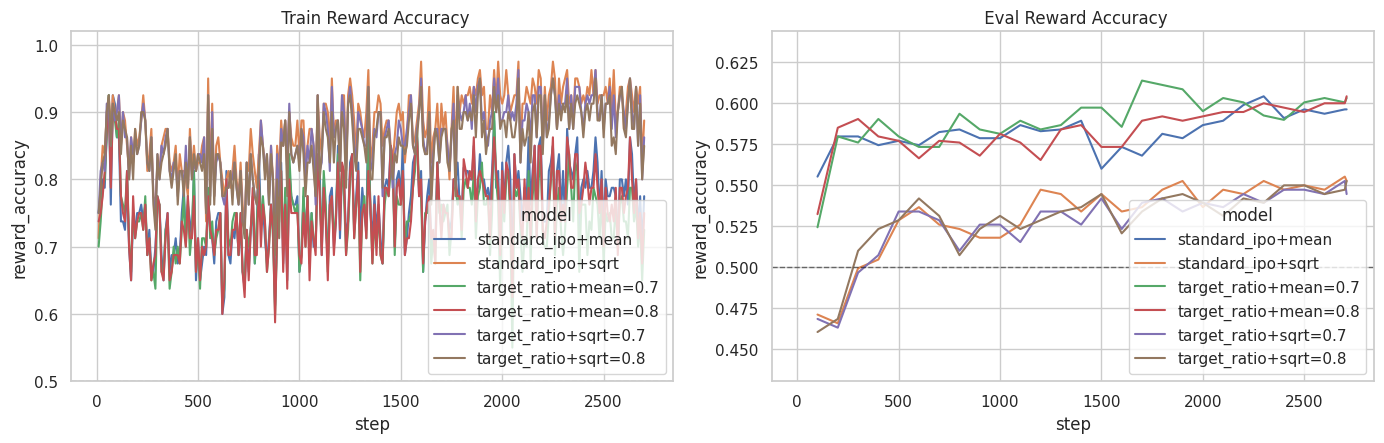

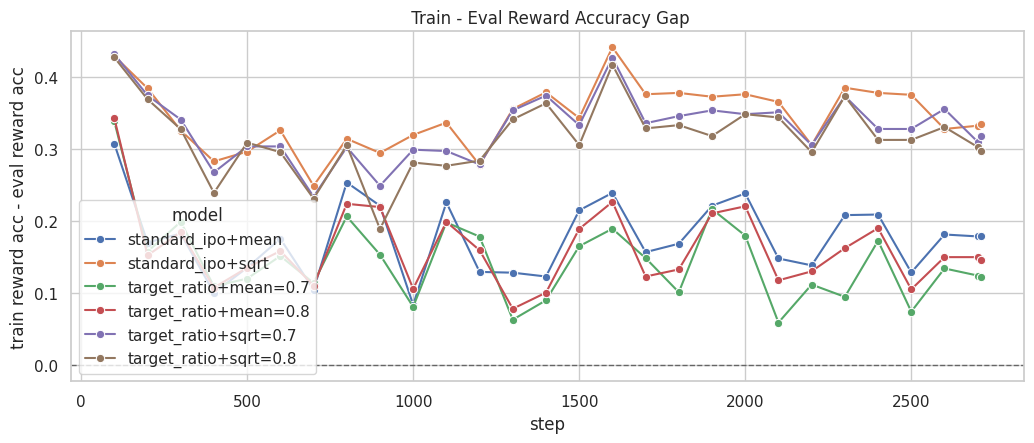

,model,step,reward_accuracy_train,reward_accuracy_eval,train_minus_eval
55,standard_ipo+sqrt,2709,0.8875,0.5527,0.3348
139,target_ratio+sqrt=0.7,2709,0.8625,0.5447,0.3178
167,target_ratio+sqrt=0.8,2709,0.8500,0.5527,0.2973
27,standard_ipo+mean,2709,0.7750,0.5963,0.1787
111,target_ratio+mean=0.8,2709,0.7500,0.6043,0.1457
83,target_ratio+mean=0.7,2709,0.7250,0.6032,0.1218


In [45]:
def plot_train_eval_accuracy_separately(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)
    for ax, split, ylim in [
        (axes[0], "train", None),
        (axes[1], "eval", None),
    ]:
        split_df = acc[acc["split"].eq(split)]
        if split_df.empty:
            ax.set_title(f"{split}: no data")
            continue
        if sns:
            sns.lineplot(data=split_df, x="step", y="reward_accuracy", hue="model", ax=ax)
        else:
            for model, g in split_df.groupby("model"):
                ax.plot(g["step"], g["reward_accuracy"], label=model)
            ax.legend()
        ax.set_title(f"{title_prefix} {split.capitalize()} Reward Accuracy")
        ax.set_xlabel("step")
        ax.set_ylabel("reward_accuracy")
        if split == "train":
            low = max(0.0, split_df["reward_accuracy"].min() - 0.05)
            ax.set_ylim(low, 1.02)
        else:
            low = max(0.0, split_df["reward_accuracy"].min() - 0.03)
            high = min(1.0, split_df["reward_accuracy"].max() + 0.03)
            ax.set_ylim(low, high)
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_accuracy_gap(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return pd.DataFrame()

    wide = (
        acc.pivot_table(index=["model", "step"], columns="split", values="reward_accuracy", aggfunc="last")
        .reset_index()
    )
    if "train" not in wide.columns or "eval" not in wide.columns:
        print("Need both train and eval reward_accuracy values to compute gap.")
        return wide

    # Eval is logged less often than train. Forward-fill train value at eval steps per model.
    rows = []
    for model, model_acc in acc.groupby("model"):
        train = model_acc[model_acc["split"].eq("train")][["step", "reward_accuracy"]].sort_values("step")
        eval_df = model_acc[model_acc["split"].eq("eval")][["step", "reward_accuracy"]].sort_values("step")
        if train.empty or eval_df.empty:
            continue
        merged = pd.merge_asof(
            eval_df,
            train,
            on="step",
            direction="backward",
            suffixes=("_eval", "_train"),
        )
        merged["model"] = model
        merged["train_minus_eval"] = merged["reward_accuracy_train"] - merged["reward_accuracy_eval"]
        rows.append(merged)

    gap_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if gap_df.empty:
        print("No gap rows computed.")
        return gap_df

    plt.figure(figsize=(10.5, 4.6))
    if sns:
        sns.lineplot(data=gap_df, x="step", y="train_minus_eval", hue="model", marker="o")
    else:
        for model, g in gap_df.groupby("model"):
            plt.plot(g["step"], g["train_minus_eval"], marker="o", label=model)
        plt.legend()
    plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.title(f"{title_prefix} Train - Eval Reward Accuracy Gap")
    plt.xlabel("step")
    plt.ylabel("train reward acc - eval reward acc")
    plt.tight_layout()
    plt.show()

    final_gap = gap_df.sort_values("step").groupby("model").tail(1)[[
        "model", "step", "reward_accuracy_train", "reward_accuracy_eval", "train_minus_eval"
    ]]
    display(final_gap.sort_values("train_minus_eval", ascending=False).round(4))
    return gap_df

plot_train_eval_accuracy_separately(curves, title_prefix="")
accuracy_gap = plot_accuracy_gap(curves, title_prefix="")

## Grouped Training Curves: Mean vs Sqrt

모델이 많아 한 그래프에 모두 그리면 해석이 어렵습니다. 아래에서는 `mean` normalization과 `sqrt` normalization을 나눠서 학습 곡선을 봅니다.

### Actual Ratio Plot 기준

Eval actual ratio는 대부분 0.5 근처에 머물러 방법 비교 시 시각적으로 큰 의미가 적으므로, actual ratio 그래프에서는 train 값만 표시합니다. Eval actual ratio는 summary table에서만 참고합니다.

Mean normalization models: ['standard_ipo+mean', 'target_ratio+mean=0.7', 'target_ratio+mean=0.8']


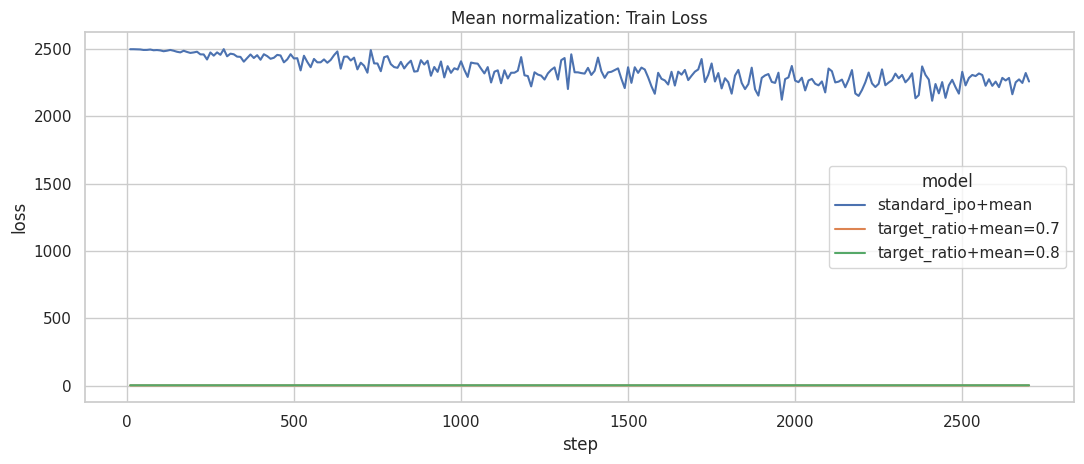

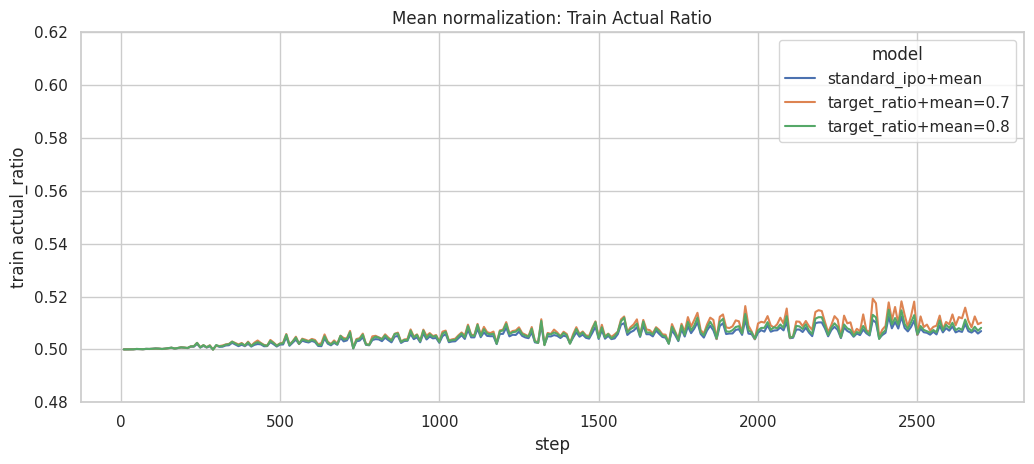

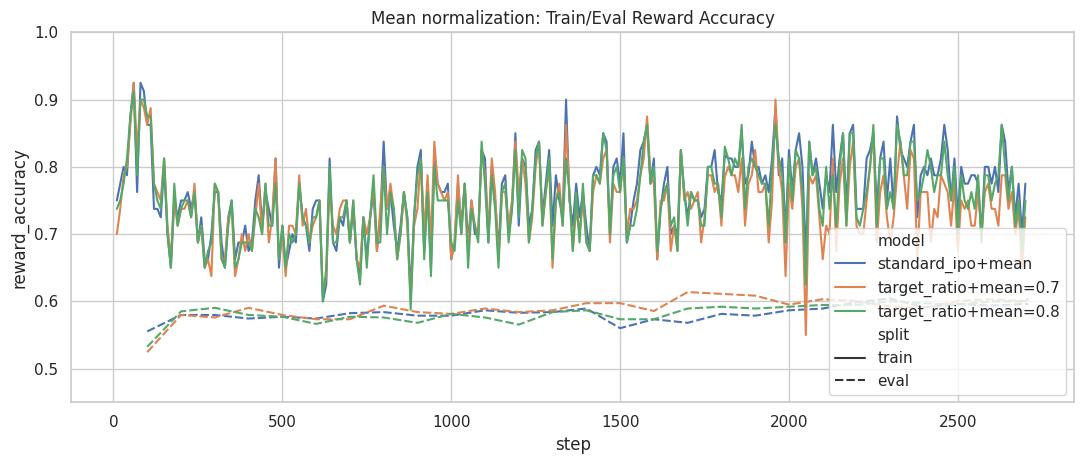

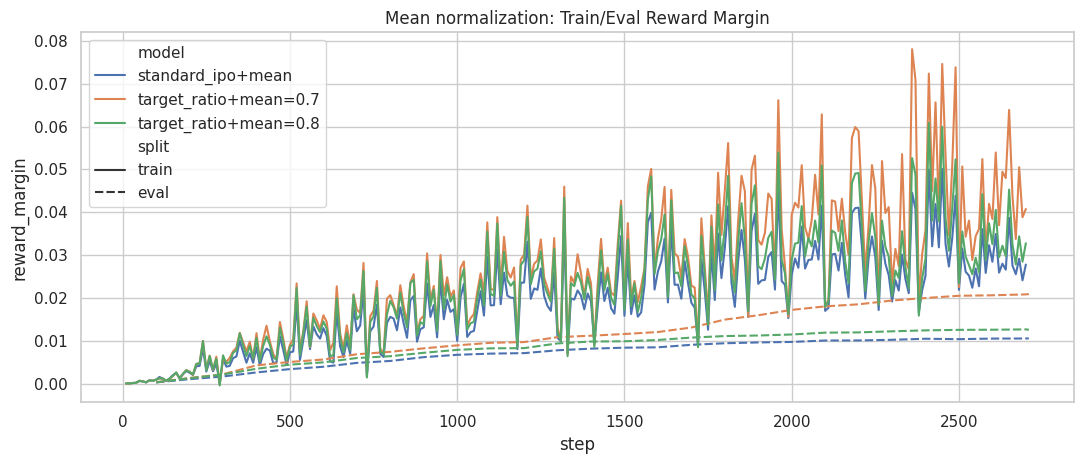

Sqrt normalization models: ['standard_ipo+sqrt', 'target_ratio+sqrt=0.7', 'target_ratio+sqrt=0.8']


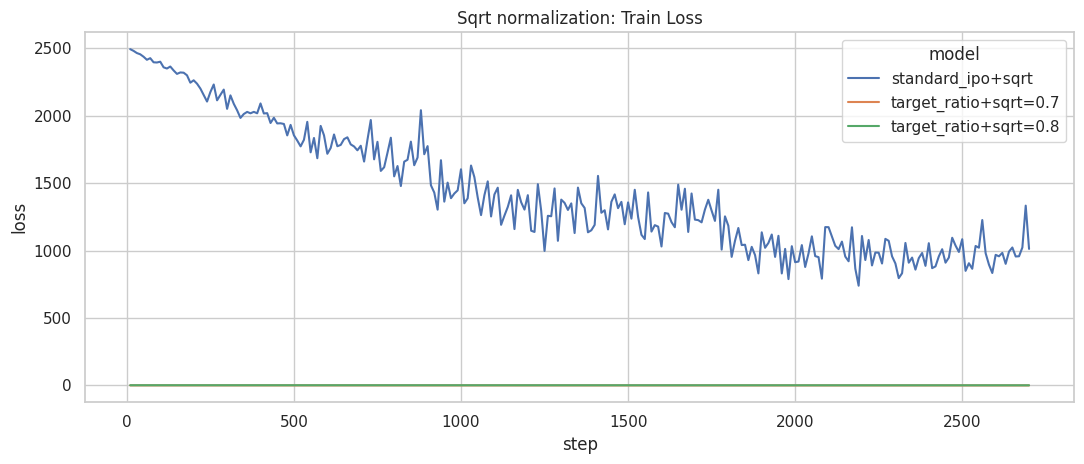

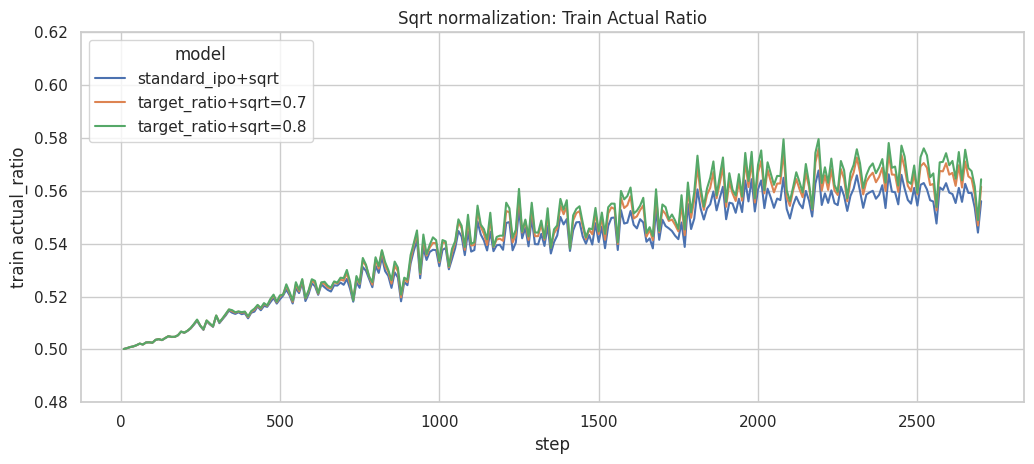

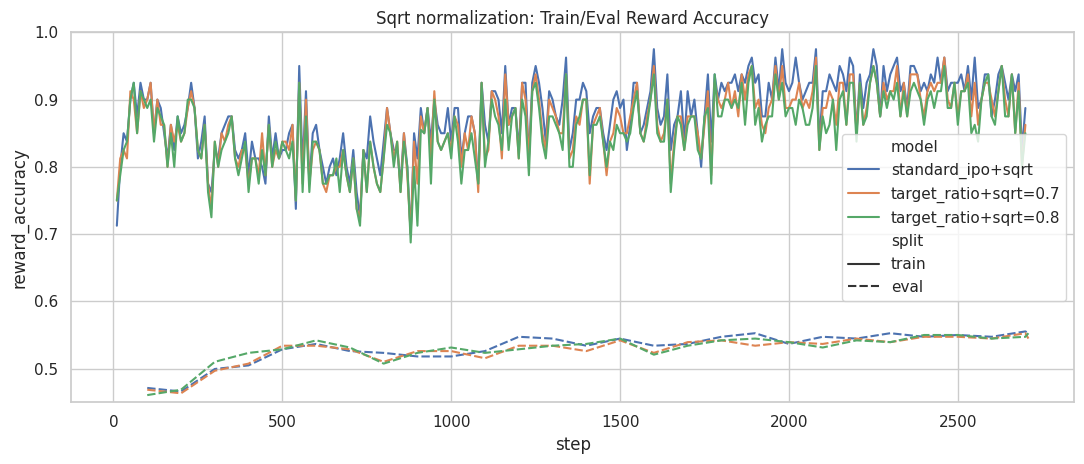

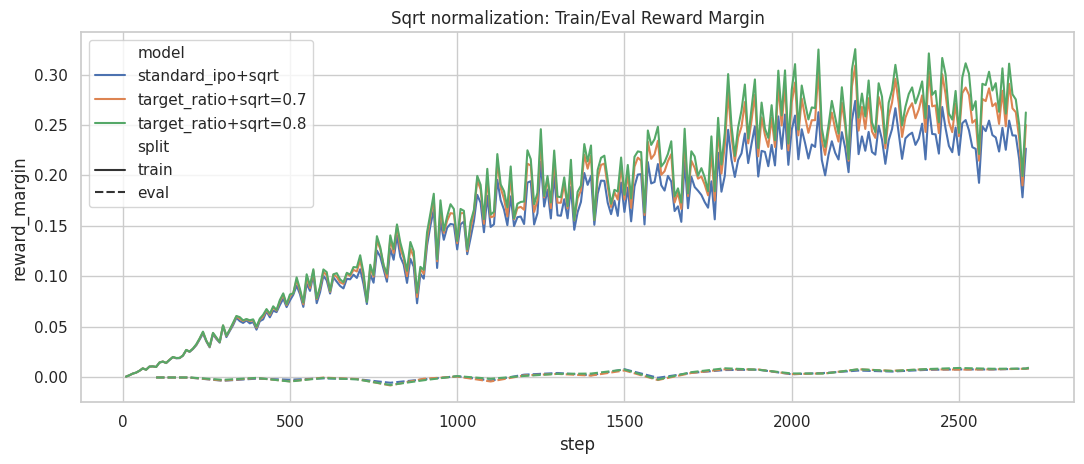

In [46]:
def plot_grouped_curves(group_name, model_names, ratio_ylim=(0.48, 0.62)):
    group_curves = curves[curves["model"].isin(model_names)].copy()
    print(f"{group_name} models:", model_names)
    lineplot_train_metric(group_curves, "loss", f"{group_name}: Train Loss")
    plot_train_actual_ratio(group_curves, f"{group_name}: Train Actual Ratio", ylim=ratio_ylim)
    lineplot_metric(group_curves, "reward_accuracy", f"{group_name}: Train/Eval Reward Accuracy", ylim=(0.45, 1.0))
    lineplot_metric(group_curves, "reward_margin", f"{group_name}: Train/Eval Reward Margin")

plot_grouped_curves("Mean normalization", mean_models)
plot_grouped_curves("Sqrt normalization", sqrt_models)


## Grouped Training Summary

학습 최종 지표도 `mean`과 `sqrt`로 나눠서 확인합니다.

In [47]:
summary_cols = [
    "model", "objective", "length_norm", "target_ratio", "global_step", "epoch",
    "final_train_actual_ratio", "final_eval_actual_ratio",
    "final_eval_reward_accuracy", "final_eval_margin",
]

mean_summary = summary[summary["length_norm"].eq("mean")][summary_cols].copy()
sqrt_summary = summary[summary["length_norm"].eq("sqrt")][summary_cols].copy()

display(mean_summary.round(4))
display(sqrt_summary.round(4))

,model,objective,length_norm,target_ratio,global_step,epoch,final_train_actual_ratio,final_eval_actual_ratio,final_eval_reward_accuracy,final_eval_margin
3,standard_ipo+mean,standard_ipo,mean,NaN,2709,3.0,0.5069,0.5026,0.5963,0.0106
5,target_ratio+mean=0.7,target_ratio,mean,0.7,2709,3.0,0.5101,0.5051,0.6032,0.0209
6,target_ratio+mean=0.8,target_ratio,mean,0.8,2709,3.0,0.5082,0.5031,0.6043,0.0126


,model,objective,length_norm,target_ratio,global_step,epoch,final_train_actual_ratio,final_eval_actual_ratio,final_eval_reward_accuracy,final_eval_margin
4,standard_ipo+sqrt,standard_ipo,sqrt,NaN,2709,3.0,0.5561,0.5022,0.5527,0.0087
7,target_ratio+sqrt=0.7,target_ratio,sqrt,0.7,2709,3.0,0.5616,0.5022,0.5447,0.0088
8,target_ratio+sqrt=0.8,target_ratio,sqrt,0.8,2709,3.0,0.5644,0.5023,0.5527,0.0095


## Benchmark: Length-Normalized Variants vs Standard IPO

Standard IPO baseline과 length-normalized variants의 task별 benchmark를 비교합니다.

In [48]:

norm_cols = ["IPO", *norm_models]
benchmark = benchmark_all[["Task", "Metric", *norm_cols]].copy()
for col in norm_models:
    benchmark[f"{col} - IPO"] = benchmark[col] - benchmark["IPO"]
benchmark.to_csv(ROOT / "outputs" / "analysis_ipo_variants" / "length_norm_vs_ipo_benchmark.csv", index=False)
benchmark


,Task,Metric,IPO,standard_ipo+mean,standard_ipo+sqrt,target_ratio+mean=0.7,target_ratio+mean=0.8,target_ratio+sqrt=0.7,target_ratio+sqrt=0.8,standard_ipo+mean - IPO,standard_ipo+sqrt - IPO,target_ratio+mean=0.7 - IPO,target_ratio+mean=0.8 - IPO,target_ratio+sqrt=0.7 - IPO,target_ratio+sqrt=0.8 - IPO
0,ARC-Challenge,acc_norm,0.3968,0.3933,0.3993,0.3908,0.3993,0.4019,0.3985,-0.0035,0.0025,-0.0060,0.0025,0.0051,0.0017
1,ARC-Easy,acc_norm,0.6700,0.6423,0.6271,0.5934,0.6237,0.6242,0.6275,-0.0277,-0.0429,-0.0766,-0.0463,-0.0458,-0.0425
2,HellaSwag,acc_norm,0.5540,0.5572,0.5605,0.5541,0.5571,0.5580,0.5580,0.0032,0.0065,0.0001,0.0031,0.0040,0.0040
3,TruthfulQA MC2,acc,0.4576,0.4937,0.4940,0.4864,0.4903,0.4953,0.4946,0.0361,0.0364,0.0288,0.0327,0.0377,0.0370
4,Winogrande,acc,0.5935,0.5722,0.5730,0.5722,0.5793,0.5667,0.5730,-0.0213,-0.0205,-0.0213,-0.0142,-0.0268,-0.0205


## Grouped Benchmark Comparison: Mean vs Sqrt

Benchmark도 `mean`과 `sqrt`를 분리해 standard IPO와 비교합니다.

Mean normalization benchmark table


,Task,Metric,IPO,standard_ipo+mean,target_ratio+mean=0.7,target_ratio+mean=0.8,standard_ipo+mean - IPO,target_ratio+mean=0.7 - IPO,target_ratio+mean=0.8 - IPO
0,ARC-Challenge,acc_norm,0.3968,0.3933,0.3908,0.3993,-0.0035,-0.0060,0.0025
1,ARC-Easy,acc_norm,0.6700,0.6423,0.5934,0.6237,-0.0277,-0.0766,-0.0463
2,HellaSwag,acc_norm,0.5540,0.5572,0.5541,0.5571,0.0032,0.0001,0.0031
3,TruthfulQA MC2,acc,0.4576,0.4937,0.4864,0.4903,0.0361,0.0288,0.0327
4,Winogrande,acc,0.5935,0.5722,0.5722,0.5793,-0.0213,-0.0213,-0.0142


,mean_score,delta_vs_IPO
IPO,0.5344,0.0000
standard_ipo+mean,0.5317,-0.0026
target_ratio+mean=0.8,0.5299,-0.0044
target_ratio+mean=0.7,0.5194,-0.0150


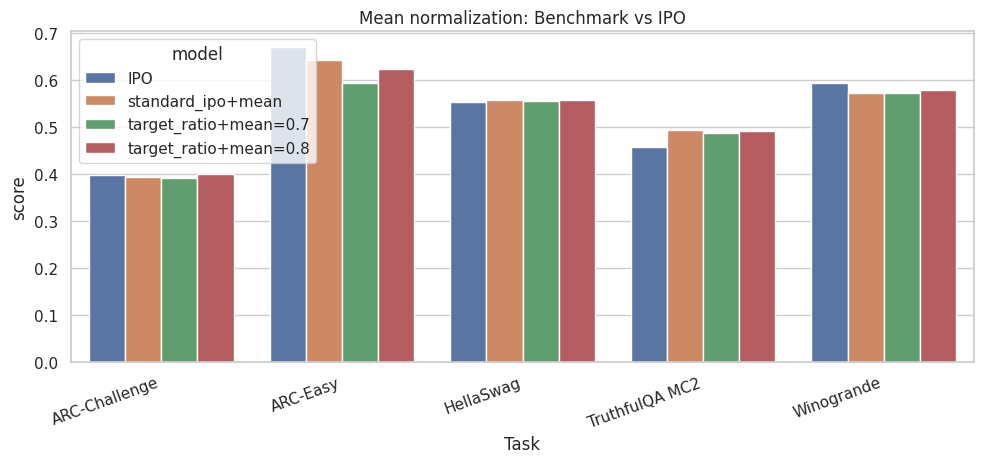

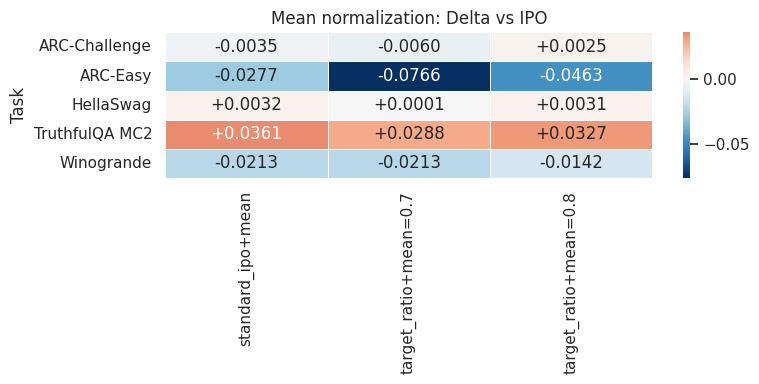

Sqrt normalization benchmark table


,Task,Metric,IPO,standard_ipo+sqrt,target_ratio+sqrt=0.7,target_ratio+sqrt=0.8,standard_ipo+sqrt - IPO,target_ratio+sqrt=0.7 - IPO,target_ratio+sqrt=0.8 - IPO
0,ARC-Challenge,acc_norm,0.3968,0.3993,0.4019,0.3985,0.0025,0.0051,0.0017
1,ARC-Easy,acc_norm,0.6700,0.6271,0.6242,0.6275,-0.0429,-0.0458,-0.0425
2,HellaSwag,acc_norm,0.5540,0.5605,0.5580,0.5580,0.0065,0.0040,0.0040
3,TruthfulQA MC2,acc,0.4576,0.4940,0.4953,0.4946,0.0364,0.0377,0.0370
4,Winogrande,acc,0.5935,0.5730,0.5667,0.5730,-0.0205,-0.0268,-0.0205


,mean_score,delta_vs_IPO
IPO,0.5344,0.0000
standard_ipo+sqrt,0.5308,-0.0036
target_ratio+sqrt=0.8,0.5303,-0.0041
target_ratio+sqrt=0.7,0.5292,-0.0052


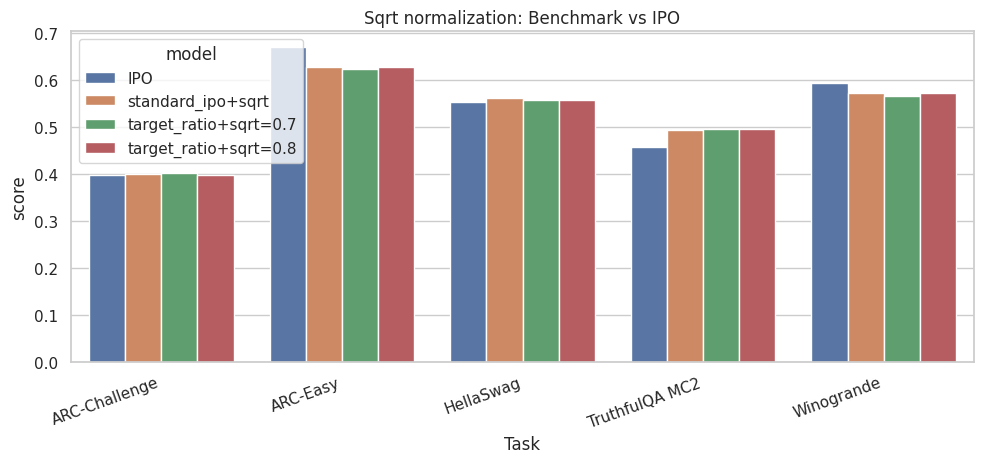

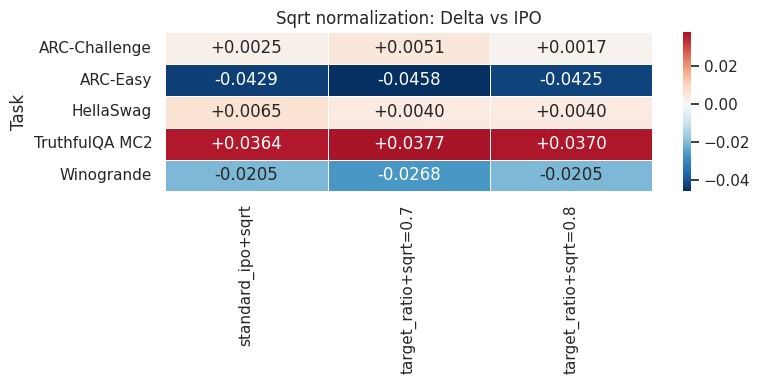

In [49]:
def display_grouped_benchmark(group_name, model_names):
    cols = ["IPO", *model_names]
    group_bench = benchmark[["Task", "Metric", *cols]].copy()
    for col in model_names:
        group_bench[f"{col} - IPO"] = group_bench[col] - group_bench["IPO"]

    print(f"{group_name} benchmark table")
    display(group_bench.round(4))

    ranking = group_bench[cols].mean().rename("mean_score").sort_values(ascending=False)
    delta = (ranking - ranking["IPO"]).rename("delta_vs_IPO")
    display(pd.concat([ranking, delta], axis=1).round(4))

    plot_df = group_bench.melt(
        id_vars=["Task", "Metric"],
        value_vars=cols,
        var_name="model",
        value_name="score",
    )
    plt.figure(figsize=(10, 4.8))
    if sns:
        sns.barplot(data=plot_df, x="Task", y="score", hue="model")
    else:
        for model, g in plot_df.groupby("model"):
            plt.plot(g["Task"], g["score"], marker="o", label=model)
        plt.legend()
    plt.xticks(rotation=20, ha="right")
    plt.title(f"{group_name}: Benchmark vs IPO")
    plt.tight_layout()
    plt.show()

    delta_cols = [f"{col} - IPO" for col in model_names]
    heatmap_df = group_bench.set_index("Task")[delta_cols]
    heatmap_df.columns = model_names
    plt.figure(figsize=(8, 4))
    if sns:
        sns.heatmap(heatmap_df, annot=True, fmt="+.4f", cmap="RdBu_r", center=0, linewidths=0.5)
    else:
        plt.imshow(heatmap_df.values, aspect="auto", cmap="RdBu_r")
        plt.colorbar()
        plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=30, ha="right")
        plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.title(f"{group_name}: Delta vs IPO")
    plt.tight_layout()
    plt.show()


display_grouped_benchmark("Mean normalization", mean_models)
display_grouped_benchmark("Sqrt normalization", sqrt_models)

In [50]:

ranking = benchmark[norm_cols].mean().rename("mean_score").sort_values(ascending=False)
delta_ranking = (ranking - ranking["IPO"]).rename("delta_vs_IPO")
pd.concat([ranking, delta_ranking], axis=1)


,mean_score,delta_vs_IPO
IPO,0.53438,0.00000
standard_ipo+mean,0.53174,-0.00264
standard_ipo+sqrt,0.53078,-0.00360
target_ratio+sqrt=0.8,0.53032,-0.00406
target_ratio+mean=0.8,0.52994,-0.00444
target_ratio+sqrt=0.7,0.52922,-0.00516
target_ratio+mean=0.7,0.51938,-0.01500


## 해석 기준

- `mean` normalization은 gap scale을 가장 강하게 줄입니다.
- `sqrt` normalization은 기존 sum-logprob gap과 mean gap 사이의 중간 형태입니다.
- norm variant의 raw loss는 standard IPO와 scale이 다를 수 있으므로 직접 비교하지 말고, actual ratio/reward accuracy/benchmark를 중심으로 해석합니다.
- 평균 benchmark가 IPO보다 낮으면 현재 beta 설정에서는 norm이 전체 성능 개선으로 이어지지 않은 것입니다.

## Benchmark Task 설명

아래 표는 사용한 benchmark task가 각각 어떤 능력을 평가하는지 정리한 것입니다.

In [51]:
task_descriptions = pd.DataFrame([
    {
        "Task": "ARC-Challenge",
        "Metric": "acc_norm",
        "평가 능력": "어려운 과학/상식 추론",
        "설명": "ARC 과학 객관식 문제 중 모델이 자주 틀리는 어려운 문제 세트입니다. 추론 난이도가 높아 preference tuning 이후 일반 추론 능력이 유지되는지 보기 좋습니다.",
    },
    {
        "Task": "ARC-Easy",
        "Metric": "acc_norm",
        "평가 능력": "기초 과학/상식 추론",
        "설명": "ARC보다 쉬운 과학 객관식 문제입니다. 기본적인 상식과 과학 지식 보존 여부를 확인합니다.",
    },
    {
        "Task": "HellaSwag",
        "Metric": "acc_norm",
        "평가 능력": "문맥 기반 상식 추론",
        "설명": "주어진 상황 뒤에 올 가장 자연스러운 문장을 고르는 task입니다. 사건 흐름과 문맥 이해 능력을 봅니다.",
    },
    {
        "Task": "TruthfulQA MC2",
        "Metric": "acc",
        "평가 능력": "진실성 / 환각 억제",
        "설명": "사람들이 오해하기 쉬운 질문에서 사실에 가까운 답을 고르는 task입니다. 선호 학습 이후 truthfulness가 유지되거나 개선되는지 봅니다.",
    },
    {
        "Task": "Winogrande",
        "Metric": "acc",
        "평가 능력": "대명사/문장 의미 추론",
        "설명": "문장 속 대명사나 빈칸이 무엇을 가리키는지 고르는 task입니다. 문법뿐 아니라 문맥과 상식 추론이 필요합니다.",
    },
])
task_descriptions

,Task,Metric,평가 능력,설명
0,ARC-Challenge,acc_norm,어려운 과학/상식 추론,ARC 과학 객관식 문제 중 모델이 자주 틀리는 어려운 문제 세트입니다. 추론 난이...
1,ARC-Easy,acc_norm,기초 과학/상식 추론,ARC보다 쉬운 과학 객관식 문제입니다. 기본적인 상식과 과학 지식 보존 여부를 확...
2,HellaSwag,acc_norm,문맥 기반 상식 추론,주어진 상황 뒤에 올 가장 자연스러운 문장을 고르는 task입니다. 사건 흐름과 문...
3,TruthfulQA MC2,acc,진실성 / 환각 억제,사람들이 오해하기 쉬운 질문에서 사실에 가까운 답을 고르는 task입니다. 선호 학...
4,Winogrande,acc,대명사/문장 의미 추론,문장 속 대명사나 빈칸이 무엇을 가리키는지 고르는 task입니다. 문법뿐 아니라 문...


## Task별 Best Model 요약

각 benchmark task에서 standard IPO와 비교했을 때 어떤 variant가 가장 좋은지 정리합니다.

In [52]:
# Length norm notebook: task별로 standard IPO 대비 가장 좋은 norm 모델을 정리합니다.
task_cols = [
    "standard_ipo+mean", "standard_ipo+sqrt",
    "target_ratio+mean=0.7", "target_ratio+mean=0.8",
    "target_ratio+sqrt=0.7", "target_ratio+sqrt=0.8",
]
task_summary_rows = []
for _, row in benchmark.iterrows():
    scores = row[task_cols]
    best_model = scores.idxmax()
    best_score = scores.max()
    ipo_score = row["IPO"]
    task_summary_rows.append({
        "Task": row["Task"],
        "Metric": row["Metric"],
        "Standard IPO": ipo_score,
        "Best norm model": best_model,
        "Best norm score": best_score,
        "Delta vs IPO": best_score - ipo_score,
        "해석": "norm이 IPO보다 높음" if best_score > ipo_score else "IPO가 norm 이상",
    })
norm_task_summary = pd.DataFrame(task_summary_rows)
norm_task_summary

,Task,Metric,Standard IPO,Best norm model,Best norm score,Delta vs IPO,해석
0,ARC-Challenge,acc_norm,0.3968,target_ratio+sqrt=0.7,0.4019,0.0051,norm이 IPO보다 높음
1,ARC-Easy,acc_norm,0.6700,standard_ipo+mean,0.6423,-0.0277,IPO가 norm 이상
2,HellaSwag,acc_norm,0.5540,standard_ipo+sqrt,0.5605,0.0065,norm이 IPO보다 높음
3,TruthfulQA MC2,acc,0.4576,target_ratio+sqrt=0.7,0.4953,0.0377,norm이 IPO보다 높음
4,Winogrande,acc,0.5935,target_ratio+mean=0.8,0.5793,-0.0142,IPO가 norm 이상


## Task별 Best Model 요약: Mean vs Sqrt 분리

Task별 best model도 `mean`과 `sqrt`를 분리해서 봅니다.

In [53]:
def task_best_summary_for_group(group_name, model_names):
    rows = []
    for _, row in benchmark.iterrows():
        scores = row[model_names]
        best_model = scores.idxmax()
        best_score = scores.max()
        ipo_score = row["IPO"]
        rows.append({
            "Group": group_name,
            "Task": row["Task"],
            "Metric": row["Metric"],
            "Standard IPO": ipo_score,
            "Best model": best_model,
            "Best score": best_score,
            "Delta vs IPO": best_score - ipo_score,
            "해석": "norm이 IPO보다 높음" if best_score > ipo_score else "IPO가 norm 이상",
        })
    return pd.DataFrame(rows)

grouped_task_summary = pd.concat([
    task_best_summary_for_group("mean", mean_models),
    task_best_summary_for_group("sqrt", sqrt_models),
], ignore_index=True)
grouped_task_summary.round(4)

,Group,Task,Metric,Standard IPO,Best model,Best score,Delta vs IPO,해석
0,mean,ARC-Challenge,acc_norm,0.3968,target_ratio+mean=0.8,0.3993,0.0025,norm이 IPO보다 높음
1,mean,ARC-Easy,acc_norm,0.6700,standard_ipo+mean,0.6423,-0.0277,IPO가 norm 이상
2,mean,HellaSwag,acc_norm,0.5540,standard_ipo+mean,0.5572,0.0032,norm이 IPO보다 높음
3,mean,TruthfulQA MC2,acc,0.4576,standard_ipo+mean,0.4937,0.0361,norm이 IPO보다 높음
4,mean,Winogrande,acc,0.5935,target_ratio+mean=0.8,0.5793,-0.0142,IPO가 norm 이상
5,sqrt,ARC-Challenge,acc_norm,0.3968,target_ratio+sqrt=0.7,0.4019,0.0051,norm이 IPO보다 높음
6,sqrt,ARC-Easy,acc_norm,0.6700,target_ratio+sqrt=0.8,0.6275,-0.0425,IPO가 norm 이상
7,sqrt,HellaSwag,acc_norm,0.5540,standard_ipo+sqrt,0.5605,0.0065,norm이 IPO보다 높음
8,sqrt,TruthfulQA MC2,acc,0.4576,target_ratio+sqrt=0.7,0.4953,0.0377,norm이 IPO보다 높음
9,sqrt,Winogrande,acc,0.5935,standard_ipo+sqrt,0.5730,-0.0205,IPO가 norm 이상
